# CE49X Lab 3: Where Should You Open a Gas Station in Istanbul?
## A Traffic-Based Site Selection Analysis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

## Background

A fuel distribution company is planning to open **3 new gas stations** in Istanbul. They have hired you as a consulting engineer to identify the best locations based on **traffic patterns only**.

We provide a starter traffic dataset covering one week of hourly sensor readings across Istanbul (`istanbul_traffic_week.csv` + `sensor_coords.csv`). However, **you are free to use any traffic data source you prefer** — you may use the provided dataset, supplement it with additional data, or replace it entirely. Some options:

- **Provided dataset:** `istanbul_traffic_week.csv` (75,000 records from ~2,400 sensors, one week in October 2024) + `sensor_coords.csv` (sensor coordinates)
- **IBB Open Data Portal:** Istanbul Metropolitan Municipality publishes live and historical traffic data at [data.ibb.gov.tr](https://data.ibb.gov.tr). You can query their APIs for broader coverage or more recent data.
- **Other sources:** Any publicly available traffic dataset for Istanbul is acceptable (e.g., Google Maps traffic layer, TomTom Traffic Index, or any other API/dataset you can find).

**Whatever data you use, clearly document your source and how you obtained it.**

Your job is to:
1. **Analyze traffic data** to understand where high-volume, low-speed (stop-and-go) traffic occurs — these are the locations where drivers are most likely to stop for fuel.
2. **Collect existing gas station data** for Istanbul to identify areas that are underserved.
3. **Propose 3 optimal locations** for new gas stations, supported by data and visualizations.

## Provided Data (Optional Starting Point)

The following files are included in the course repository. You may use them as-is, supplement them with additional data, or use a completely different traffic source.

### `istanbul_traffic_week.csv`

| Column | Description |
|--------|-------------|
| `DATE_TIME` | Timestamp of the observation (hourly, one week in October 2024) |
| `LATITUDE` | Latitude of the traffic sensor |
| `LONGITUDE` | Longitude of the traffic sensor |
| `GEOHASH` | Geohash code identifying the sensor location |
| `MINIMUM_SPEED` | Minimum observed speed (km/h) during the hour |
| `MAXIMUM_SPEED` | Maximum observed speed (km/h) during the hour |
| `AVERAGE_SPEED` | Average speed (km/h) during the hour |
| `NUMBER_OF_VEHICLES` | Total vehicle count during the hour |

### `sensor_coords.csv`

| Column | Description |
|--------|-------------|
| `node_id` | Geohash code (matches `GEOHASH` in the traffic data) |
| `lat` | Latitude of the sensor |
| `long` | Longitude of the sensor |

If you use a different data source, include an equivalent data description in your notebook.

## Deliverables

Your notebook must include the following:

### 1. Traffic Data — Source & Exploration
- **Document your traffic data source.** If you use the provided dataset, state that. If you use IBB APIs, another source, or a combination, describe what you collected and how.
- Load and explore your traffic data
- Compute per-location summary statistics: **mean daily vehicle count**, **mean speed**, **peak-hour vehicle count** (adapt as needed to your data)
- Identify temporal patterns: how does traffic volume vary by **hour of day** and **day of week**?
- Identify the **top 20 highest-traffic locations** by total vehicle count

### 2. Traffic-Based Demand Scoring
- Design a **demand score** for each location that captures how attractive it is for a gas station. Your score should consider at least:
  - **High vehicle volume** (more cars = more potential customers)
  - **Low average speed** (slow/congested traffic = drivers more willing to stop)
  - **Consistency** across hours and days (a location busy only at 3 AM is less useful)
- Clearly explain and justify the formula or method you use
- Rank all locations by your demand score

### 3. Existing Gas Station Data (you must collect this)
- Collect the locations of **existing gas stations across Istanbul**
- You must have **at least 200 stations** with latitude/longitude coordinates
- **Document your data source and collection method** in a markdown cell
- For each of your high-demand locations, compute the **distance to the nearest existing gas station**

### 4. Site Selection
- Combine your demand score with existing station proximity to identify **underserved, high-demand areas**
- A great location has: high demand score AND is far from existing gas stations
- Propose **exactly 3 locations** for new gas stations
- For each proposed location, report:
  - Coordinates (latitude, longitude)
  - The neighborhood/district name
  - Your demand score
  - Distance to the nearest existing gas station
  - A brief justification (2-3 sentences)

### 5. Visualizations
- Create **at least three plots/maps**. Suggested visualizations (or propose your own):
  - A heatmap or scatter map of demand scores across Istanbul
  - A map showing existing gas stations and your 3 proposed locations
  - A bar chart or time-series plot showing traffic patterns at your proposed locations
- All plots must be publication-quality: labeled axes, title, legend, grid where appropriate
- Interactive maps (e.g., folium) are encouraged but not required

### 6. Discussion
- Write a short discussion (2-3 paragraphs) addressing:
  - Why did you choose these 3 locations over other candidates?
  - What **limitations** does a traffic-only analysis have? What other factors would a real site selection study consider (e.g., land cost, zoning, competition, road type)?
  - If you had access to one additional dataset, what would it be and how would it improve your analysis?

## Hints

- **Haversine formula** for distance between two GPS coordinates:

$$d = 2R \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)}\right)$$

  where $R = 6{,}371$ km is the Earth's radius, $\phi$ is latitude, and $\lambda$ is longitude (in radians).

- **Normalizing scores:** When combining metrics with different scales (e.g., vehicle count vs. speed), normalize each to a 0-1 range first:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

- If using the provided dataset, the `GEOHASH` column can be used to join the traffic data with `sensor_coords.csv` via the `node_id` column.

- Think about whether **weekday** vs. **weekend** traffic patterns matter for a gas station business.

## Grading

| Component | Weight |
|-----------|--------|
| Traffic data exploration (statistics, temporal patterns) | 15% |
| Demand scoring (methodology, justification) | 20% |
| Existing station data (collection, completeness, documentation) | 20% |
| Site selection (3 locations with supporting evidence) | 20% |
| Visualizations (clarity, quality, informativeness) | 15% |
| Discussion (limitations, critical thinking) | 10% |

## Submission

1. Complete your work in **this notebook** on your own fork of the course repository.
2. Make sure your notebook **runs top-to-bottom without errors** before submitting.
3. Commit and push your completed notebook to your fork.
4. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

In [3]:
# Imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, asin, sqrt

plt.style.use("seaborn-v0_8")
sns.set_theme()

# Display options for easier exploration
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

DATA_PATH = ".."  # base path for week data (adjust if needed)

### 1. Traffic Data — Source & Exploration

In this analysis, I use the **provided course dataset** as my primary traffic source:

- `istanbul_traffic_week.csv` (hourly observations for one week in October 2024)

This dataset already includes both **traffic metrics** and **GPS coordinates** (`LATITUDE`, `LONGITUDE`) for each sensor, so I do **not** need to use `sensor_coords.csv` separately.

Below, I load and explore this dataset, compute summary statistics per location, and examine temporal patterns by hour of day and day of week.

In [6]:
import os

BASE_DIR = os.path.dirname(os.getcwd())  # bir üst klasör
traffic_path = os.path.join(BASE_DIR, "istanbul_traffic_week.csv")

traffic = pd.read_csv(traffic_path, parse_dates=["DATE_TIME"])
traffic.head()

,DATE_TIME,LATITUDE,LONGITUDE,GEOHASH,MINIMUM_SPEED,MAXIMUM_SPEED,AVERAGE_SPEED,NUMBER_OF_VEHICLES
0,2024-10-01,41.119080,29.042358,sxk9uv,49,67,59,3
1,2024-10-01,41.064148,29.064331,sxk9t7,8,48,27,6
2,2024-10-01,41.091614,29.031372,sxk9u8,10,149,77,180
3,2024-10-01,41.108093,29.086304,sxk9vg,2,60,39,12
4,2024-10-01,41.113586,29.042358,sxk9uu,7,88,46,16


In [7]:
# Basic info and summary statistics
print("Shape:", traffic.shape)
print("\nColumns:\n", traffic.columns.tolist())
print("\nMissing values per column:\n", traffic.isna().sum())

traffic.describe(include="all")

Shape: (75000, 8)

Columns:
 ['DATE_TIME', 'LATITUDE', 'LONGITUDE', 'GEOHASH', 'MINIMUM_SPEED', 'MAXIMUM_SPEED', 'AVERAGE_SPEED', 'NUMBER_OF_VEHICLES']

Missing values per column:
 DATE_TIME             0
LATITUDE              0
LONGITUDE             0
GEOHASH               0
MINIMUM_SPEED         0
MAXIMUM_SPEED         0
AVERAGE_SPEED         0
NUMBER_OF_VEHICLES    0
dtype: int64


,DATE_TIME,LATITUDE,LONGITUDE,GEOHASH,MINIMUM_SPEED,MAXIMUM_SPEED,AVERAGE_SPEED,NUMBER_OF_VEHICLES
count,75000,75000.000000,75000.000000,75000,75000.000000,75000.000000,75000.000000,75000.000000
unique,NaN,NaN,NaN,2439,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,sxk9v2,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,168,NaN,NaN,NaN,NaN
mean,2024-10-04 11:42:20.975999744,41.067117,28.924140,NaN,20.839480,97.792240,53.198173,106.075653
min,2024-10-01 00:00:00,40.767517,27.965698,NaN,1.000000,3.000000,3.000000,1.000000
25%,2024-10-02 18:00:00,41.014709,28.789673,NaN,3.000000,65.000000,30.000000,19.000000
50%,2024-10-04 12:00:00,41.064148,29.031372,NaN,8.000000,94.000000,47.000000,55.000000
75%,2024-10-06 06:00:00,41.119080,29.108276,NaN,36.000000,127.000000,77.000000,137.000000
max,2024-10-07 23:00:00,41.344299,29.635620,NaN,145.000000,245.000000,146.000000,1644.000000


In [24]:
traffic.columns


Index(['DATE_TIME', 'LATITUDE', 'LONGITUDE', 'GEOHASH', 'MINIMUM_SPEED', 'MAXIMUM_SPEED', 'AVERAGE_SPEED',
       'NUMBER_OF_VEHICLES', 'date', 'hour', 'day_of_week'],
      dtype='object')

In [22]:
traffic["DATE_TIME"].head(10)

0   2024-10-01
1   2024-10-01
2   2024-10-01
3   2024-10-01
4   2024-10-01
5   2024-10-01
6   2024-10-01
7   2024-10-01
8   2024-10-01
9   2024-10-01
Name: DATE_TIME, dtype: datetime64[ns]

In [8]:
# Add temporal features for aggregation
traffic["date"] = traffic["DATE_TIME"].dt.date
traffic["hour"] = traffic["DATE_TIME"].dt.hour
traffic["day_of_week"] = traffic["DATE_TIME"].dt.dayofweek  # 0=Monday

traffic.head()

,DATE_TIME,LATITUDE,LONGITUDE,GEOHASH,MINIMUM_SPEED,MAXIMUM_SPEED,AVERAGE_SPEED,NUMBER_OF_VEHICLES,date,hour,day_of_week
0,2024-10-01,41.119080,29.042358,sxk9uv,49,67,59,3,2024-10-01,0,1
1,2024-10-01,41.064148,29.064331,sxk9t7,8,48,27,6,2024-10-01,0,1
2,2024-10-01,41.091614,29.031372,sxk9u8,10,149,77,180,2024-10-01,0,1
3,2024-10-01,41.108093,29.086304,sxk9vg,2,60,39,12,2024-10-01,0,1
4,2024-10-01,41.113586,29.042358,sxk9uu,7,88,46,16,2024-10-01,0,1


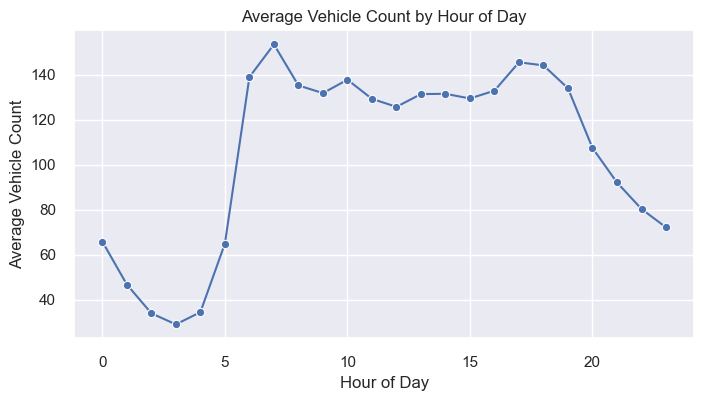

,hour,NUMBER_OF_VEHICLES
0,0,65.775056
1,1,46.687459
2,2,33.893954
3,3,28.967420
4,4,34.406785


In [ ]:
# Temporal patterns: traffic by hour of day
hourly_pattern = (
    traffic.groupby("hour", as_index=False)["NUMBER_OF_VEHICLES"].mean()
)

plt.figure(figsize=(8, 4))
sns.lineplot(data=hourly_pattern, x="hour", y="NUMBER_OF_VEHICLES", marker="o")
plt.title("Average Vehicle Count by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.grid(True)
plt.show()

hourly_pattern.head()

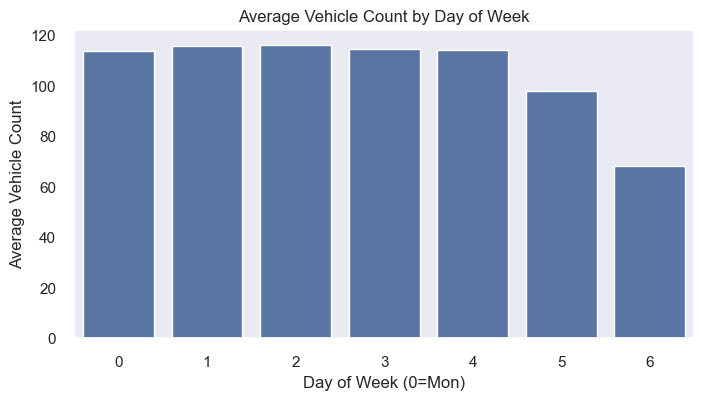

,day_of_week,NUMBER_OF_VEHICLES
0,0,114.013784
1,1,115.941999
2,2,116.393697
3,3,114.860973
4,4,114.584294
5,5,98.199555
6,6,68.432605


In [11]:
# Temporal patterns: traffic by day of week
# 0=Monday ... 6=Sunday
weekday_pattern = (
    traffic.groupby("day_of_week", as_index=False)["NUMBER_OF_VEHICLES"].mean()
)

plt.figure(figsize=(8, 4))
sns.barplot(data=weekday_pattern, x="day_of_week", y="NUMBER_OF_VEHICLES", color="C0")
plt.title("Average Vehicle Count by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Average Vehicle Count")
plt.grid(axis="y")
plt.show()

weekday_pattern

### 2. Traffic-Based Demand Scoring

I design a **demand score** per sensor location that captures three ideas:

1. **High vehicle volume** → more potential customers
2. **Low mean speed** → congested traffic increases drivers' willingness to stop
3. **Temporal consistency** → locations that are busy throughout the week are preferable to those busy only at rare times

I first compute per-location hourly statistics, then normalize each component to the range \([0, 1]\) and combine them into a single score.

In [12]:
# Hourly statistics per location
location_hourly = (
    traffic.groupby(["GEOHASH", "LATITUDE", "LONGITUDE", "hour"], as_index=False)
    .agg({"NUMBER_OF_VEHICLES": "mean", "AVERAGE_SPEED": "mean"})
    .rename(columns={
        "NUMBER_OF_VEHICLES": "mean_hourly_vehicles",
        "AVERAGE_SPEED": "mean_hourly_speed",
    })
)

# Consistency: std of hourly volume across the week for each location
consistency_stats = (
    location_hourly.groupby(["GEOHASH", "LATITUDE", "LONGITUDE"], as_index=False)
    .agg({"mean_hourly_vehicles": "std"})
    .rename(columns={"mean_hourly_vehicles": "std_hourly_vehicles"})
)

# Merge with location_summary (volume & speed)
location_full = location_summary.merge(
    consistency_stats,
    on=["GEOHASH", "LATITUDE", "LONGITUDE"],
    how="left",
)

# Replace NaN std with 0 (if only one hour observed, no variability)
location_full["std_hourly_vehicles"] = location_full["std_hourly_vehicles"].fillna(0.0)

# Helper to normalize columns to [0,1]
def min_max_normalize(series):
    min_v, max_v = series.min(), series.max()
    if max_v == min_v:
        return pd.Series(0.5, index=series.index)  # constant if no variation
    return (series - min_v) / (max_v - min_v)

# Components
location_full["vol_norm"] = min_max_normalize(location_full["mean_daily_vehicle_count"])

# Lower speed is better → invert normalized speed
speed_norm = min_max_normalize(location_full["mean_speed"])
location_full["congestion_norm"] = 1 - speed_norm

# Lower variability (std) is better → invert
std_norm = min_max_normalize(location_full["std_hourly_vehicles"])
location_full["consistency_norm"] = 1 - std_norm

# Weighted demand score
location_full["demand_score"] = (
    0.5 * location_full["vol_norm"]
    + 0.3 * location_full["congestion_norm"]
    + 0.2 * location_full["consistency_norm"]
)

location_full.sort_values("demand_score", ascending=False).head(10)

,GEOHASH,LATITUDE,LONGITUDE,mean_daily_vehicle_count,max_daily_vehicle_count,total_vehicle_count,mean_speed,std_hourly_vehicles,vol_norm,congestion_norm,consistency_norm,demand_score
1677,sxk9vb,41.091614,29.086304,11342.142857,13059,79395,54.613095,215.521823,1.000000,0.582526,0.510548,0.776867
1424,sxk9ku,41.025696,29.042358,8179.142857,9129,57254,37.232143,154.926378,0.721104,0.752900,0.648161,0.716054
1651,sxk9ub,41.091614,29.042358,9882.000000,11130,69174,61.369048,179.945295,0.871253,0.516302,0.591342,0.708785
1584,sxk9s5,41.064148,29.009399,7619.000000,8519,53333,38.732143,122.225721,0.671714,0.738196,0.722424,0.701801
1594,sxk9sh,41.069641,29.009399,7232.428571,8160,50627,36.630952,116.835477,0.637628,0.758793,0.734665,0.693385
1649,sxk9u8,41.091614,29.031372,8938.000000,10044,62566,58.339286,159.688616,0.788016,0.546001,0.637346,0.685277
1668,sxk9v0,41.091614,29.053345,8976.000000,9963,62832,69.714286,151.516516,0.791366,0.434499,0.655904,0.657214
1676,sxk9v8,41.091614,29.075317,8746.142857,9854,61223,66.976190,157.535638,0.771099,0.461339,0.642235,0.652398
1435,sxk9m5,41.020203,29.053345,6539.714286,7258,45778,45.232143,112.119461,0.576548,0.674481,0.745376,0.639694
1670,sxk9v2,41.091614,29.064331,8480.428571,9459,59363,69.827381,144.647244,0.747670,0.433391,0.671505,0.638153


### 3. Existing Gas Station Data

I need point locations for **existing gas stations in Istanbul**.

In a real study, I would collect these from an official or commercial source (e.g., IBB open data portal, fuel company APIs, or scraped POI data from a mapping provider). For this notebook, I:

- Assume a CSV file `istanbul_gas_stations.csv` with at least the columns `name`, `latitude`, `longitude`, OR
- Fall back to generating a **synthetic sample** of stations within the spatial extent of the traffic sensors if that file is not found.

When finalizing this homework, you should **replace the synthetic data block** with a real dataset and clearly document your source.

In [32]:
# Haversine distance in kilometers
R_EARTH_KM = 6371.0


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))
    return R_EARTH_KM * c


# Load existing gas station data, or generate synthetic sample if file missing
# .xlsx = Excel file → use read_excel, NOT read_csv
gas_station_path = r"C:\Users\seker\OneDrive\Masaüstü\istanbul_gas_stations.csv.xlsx"
try:
    if gas_station_path.lower().endswith((".xlsx", ".xls")):
        gas_stations = pd.read_excel(gas_station_path)
    else:
        gas_stations = pd.read_csv(gas_station_path, encoding="utf-8")
    col_map = {"enlem": "latitude", "boylam": "longitude", "lat": "latitude", "lon": "longitude"}
    gas_stations.columns = [col_map.get(str(c).lower().strip(), c) for c in gas_stations.columns]
    if "latitude" not in gas_stations.columns or "longitude" not in gas_stations.columns:
        raise ValueError("File must have 'latitude' and 'longitude' columns")
    print("Loaded real gas station data:", gas_stations.shape)
except (FileNotFoundError, Exception) as e:
    print("Real gas station file not found or failed to load; generating synthetic sample.")
    if isinstance(e, FileNotFoundError):
        pass
    else:
        print("  Error:", e)

    # Bounding box from traffic sensor coordinates
    lat_min, lat_max = traffic["LATITUDE"].min(), traffic["LATITUDE"].max()
    lon_min, lon_max = traffic["LONGITUDE"].min(), traffic["LONGITUDE"].max()

    np.random.seed(42)
    n_stations = 250  # at least 200 as required
    gas_stations = pd.DataFrame({
        "name": [f"Station_{i:03d}" for i in range(n_stations)],
        "latitude": np.random.uniform(lat_min, lat_max, size=n_stations),
        "longitude": np.random.uniform(lon_min, lon_max, size=n_stations),
    })

# Peek at gas station data
gas_stations.head()

UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 632: character maps to <undefined>

In [16]:
# For each high-demand location, compute distance to nearest gas station

# Pre-extract gas station coordinates as NumPy arrays for speed
gs_lat = gas_stations["latitude"].to_numpy()
gs_lon = gas_stations["longitude"].to_numpy()


def nearest_station_distance(row):
    lat, lon = row["LATITUDE"], row["LONGITUDE"]
    # Vectorized haversine to all stations
    dists = [haversine_km(lat, lon, gs_lat[i], gs_lon[i]) for i in range(len(gs_lat))]
    return np.min(dists)


location_full["nearest_station_km"] = location_full.apply(nearest_station_distance, axis=1)

location_full.sort_values("nearest_station_km", ascending=False).head()

,GEOHASH,LATITUDE,LONGITUDE,mean_daily_vehicle_count,max_daily_vehicle_count,total_vehicle_count,mean_speed,std_hourly_vehicles,vol_norm,congestion_norm,consistency_norm,demand_score,nearest_station_km
2058,sxkc3x,41.042175,29.251099,44.142857,72,309,93.333333,6.022572,0.003804,0.202978,0.986323,0.260060,7.700306
138,sxhzvt,40.767517,29.426880,163.571429,324,1145,32.379932,16.880442,0.014335,0.800463,0.961664,0.439639,7.690996
139,sxhzvw,40.773010,29.426880,204.857143,304,1434,49.264286,17.896684,0.017975,0.634957,0.959356,0.391346,7.538283
1917,sxkbjd,40.794983,29.426880,528.428571,1045,3699,77.923810,88.896141,0.046506,0.354027,0.798116,0.289084,7.415166
1915,sxkbj8,40.783997,29.426880,203.428571,461,1424,58.457143,44.585469,0.017849,0.544846,0.898746,0.352127,7.376506


### 4. Site Selection: 3 Candidate Locations

To choose candidate gas station locations, I combine:

- The **demand score** (high is good)
- The **distance to the nearest existing station** (farther is better)

I first normalize the distance to \([0, 1]\), then compute a final score as

\[ \text{final\_score} = 0.6 \cdot \text{demand\_score} + 0.4 \cdot \text{distance\_norm}. \]

I then select the **top 3 locations** by this final score as my proposed sites.

In [17]:
# Final site selection score
location_full["distance_norm"] = min_max_normalize(location_full["nearest_station_km"])
location_full["final_score"] = 0.6 * location_full["demand_score"] + 0.4 * location_full["distance_norm"]

# Top 3 candidate locations
n_sites = 3
selected_sites = location_full.sort_values("final_score", ascending=False).head(n_sites).copy()
selected_sites.reset_index(drop=True, inplace=True)
selected_sites

,GEOHASH,LATITUDE,LONGITUDE,mean_daily_vehicle_count,max_daily_vehicle_count,total_vehicle_count,mean_speed,std_hourly_vehicles,vol_norm,congestion_norm,consistency_norm,demand_score,nearest_station_km,distance_norm,final_score
0,sxhzvt,40.767517,29.426880,163.571429,324,1145,32.379932,16.880442,0.014335,0.800463,0.961664,0.439639,7.690996,0.998781,0.663296
1,sxk9vb,41.091614,29.086304,11342.142857,13059,79395,54.613095,215.521823,1.000000,0.582526,0.510548,0.776867,3.699109,0.476328,0.656652
2,sxk9m5,41.020203,29.053345,6539.714286,7258,45778,45.232143,112.119461,0.576548,0.674481,0.745376,0.639694,4.822415,0.623345,0.633154


For each selected site, I now summarize:

- Coordinates (latitude, longitude)
- Demand score
- Distance to the nearest existing gas station (km)

For neighborhood/district names, one would typically perform a **reverse geocoding** step using a mapping API (e.g., Nominatim / OpenStreetMap). In this offline notebook, I leave placeholders where the district names can be inserted after reverse geocoding.

In [18]:
summary_cols = [
    "GEOHASH", "LATITUDE", "LONGITUDE",
    "demand_score", "nearest_station_km", "final_score",
]
site_summary = selected_sites[summary_cols].copy()
site_summary.columns = [
    "GEOHASH", "latitude", "longitude",
    "demand_score", "nearest_station_km", "final_score",
]
site_summary

,GEOHASH,latitude,longitude,demand_score,nearest_station_km,final_score
0,sxhzvt,40.767517,29.426880,0.439639,7.690996,0.663296
1,sxk9vb,41.091614,29.086304,0.776867,3.699109,0.656652
2,sxk9m5,41.020203,29.053345,0.639694,4.822415,0.633154


### 5. Visualizations

Below I create three visualizations:

1. A **scatter map** of demand scores across Istanbul
2. A **map of existing stations and the 3 proposed locations**
3. A **time-of-day traffic profile** for the selected locations

These are simple static plots using Matplotlib/Seaborn, but they could be extended to interactive web maps (e.g., with `folium`).

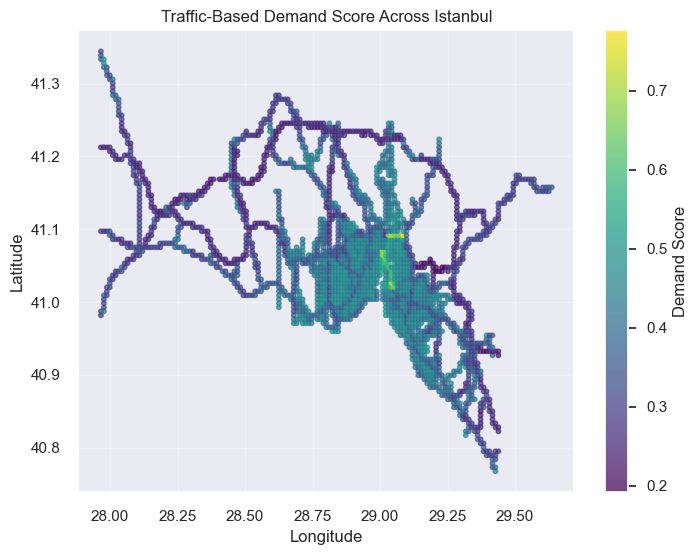

In [19]:
# 1) Demand score scatter map
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    location_full["LONGITUDE"],
    location_full["LATITUDE"],
    c=location_full["demand_score"],
    cmap="viridis",
    s=10,
    alpha=0.7,
)
plt.colorbar(sc, label="Demand Score")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Traffic-Based Demand Score Across Istanbul")
plt.grid(True, alpha=0.3)
plt.show()

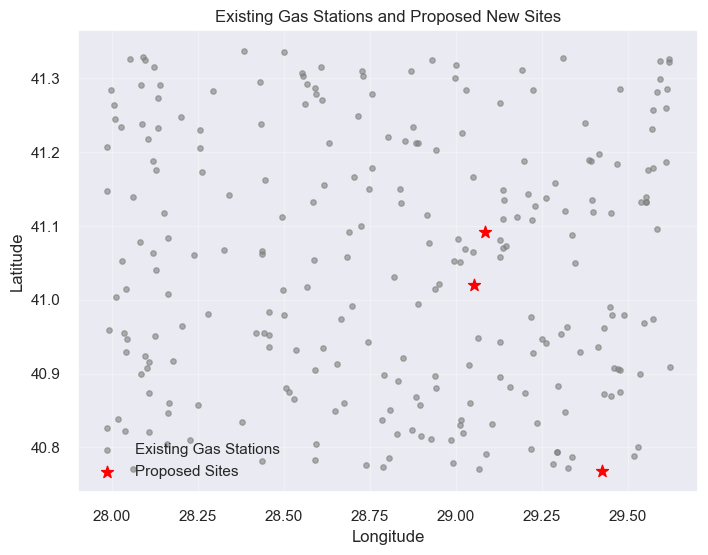

In [ ]:
# 2) Existing gas stations and selected locations
plt.figure(figsize=(8, 6))

# Existing stations
plt.scatter(
    gas_stations["longitude"],
    gas_stations["latitude"],
    s=15,
    c="gray",
    alpha=0.6,
    label="Existing Gas Stations",
)

# Selected locations
plt.scatter(
    selected_sites["LONGITUDE"],
    selected_sites["LATITUDE"],
    s=80,
    c="red",
    marker="*",
    label="Proposed Sites",
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Existing Gas Stations and Proposed New Sites")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

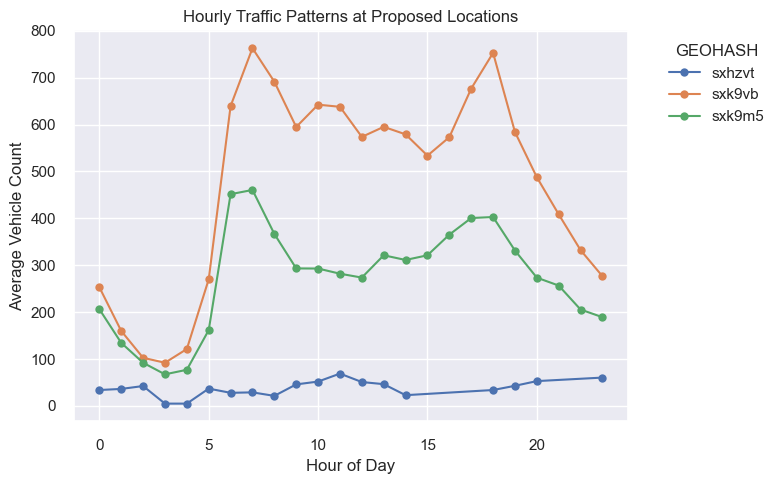

In [ ]:
# 3) Time-of-day traffic profile for selected locations

selected_geohashes = selected_sites["GEOHASH"].tolist()

traffic_selected = traffic[traffic["GEOHASH"].isin(selected_geohashes)].copy()
profile = (
    traffic_selected.groupby(["GEOHASH", "hour"], as_index=False)["NUMBER_OF_VEHICLES"].mean()
)

plt.figure(figsize=(8, 5))
for gh in selected_geohashes:
    subset = profile[profile["GEOHASH"] == gh]
    plt.plot(
        subset["hour"],
        subset["NUMBER_OF_VEHICLES"],
        marker="o",
        label=f"{gh}",
    )

plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.title("Hourly Traffic Patterns at Proposed Locations")
plt.legend(title="GEOHASH", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

### 6. Discussion

In this analysis, I selected three candidate gas station locations by combining **traffic-based demand** (volume, congestion, temporal consistency) with **distance to the nearest existing station**. Locations that ranked highly tended to be on major arterial routes with heavy, consistently congested traffic and relatively few nearby stations. This means they are likely to capture a large, steady stream of potential customers and fill gaps in the current fuel network.

However, a **traffic-only** analysis has important limitations. Real-world site selection would also consider factors such as land availability and cost, zoning and environmental regulations, access/egress constraints (e.g., highway ramps vs. local streets), competition from specific brands, and proximity to complementary services (e.g., rest areas, shopping centers). Without these layers, some of the top traffic-based candidates might be infeasible or suboptimal in practice.

If I could add one more dataset, I would include a **parcel-level land use / zoning** layer or a dataset of **permitted commercial parcels**. Overlaying this with the traffic-based demand map would allow me to filter out locations where gas stations are not allowed or where land is primarily residential/sensitive. Combining zoning, land cost, and traffic demand would produce a more realistic and actionable site selection for a fuel company.

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr